# Appendix D: Validation results per year

The structure of this notebook is as follows:

### 1. Startup
### 2. Model Setup
### 3. Running model
### 4. Display Results

## 1. Startup

In [21]:
# General python
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr

# Niceties
from rich import print

In [22]:
# General eWaterCycle
import ewatercycle
import ewatercycle.models
import ewatercycle.forcing

In [23]:
# Defining things

basin_size = 132572
q_critical = 500

# Choosing time period

validation_start_yr = 2019
validation_end_yr = 2024

experiment_start_date = f"{validation_start_yr}-01-01T00:00:00Z"
experiment_end_date = f"{validation_end_yr}-12-31T00:00:00Z"

validation_start = f"{validation_start_yr}-01-01T00:00:00Z"
validation_end = f"{validation_end_yr}-12-31T00:00:00Z"

In [24]:
# Create pathways for ERA 5 forcings

forcing_path_ERA5 = Path.home() / "BEP-maxime" / "book" / "thesis_projects" / "BSc" / "2026_Q4_MaximedeBekker_CEG" /  "Workyard" / "forcings" / "ERA5" / f"ERA5-{validation_start_yr}-{validation_end_yr}"

discharge_file = Path.home() / "BEP-maxime" / "book" / "thesis_projects" / "BSc" / "2026_Q4_MaximedeBekker_CEG" /  "Workyard" / "07DA001_discharge_daily_withoutmissing.csv"

shape_file = Path.home() / "BEP-maxime" / "book" / "thesis_projects" / "BSc" / "2026_Q4_MaximedeBekker_CEG" /  "Workyard" / "Shapefiles" / "07DA001_basin.shp"

hbv_config = Path.home() / "BEP-maxime" / "book" / "thesis_projects" / "BSc" / "2026_Q4_MaximedeBekker_CEG" /  "Workyard" / "hbv_config"
hbv_config.mkdir(parents=True, exist_ok=True)

In [25]:
# Load CSV discharge 07DA001

q_obs = pd.read_csv(discharge_file, skiprows=1)
q_obs = q_obs[["Date", "Value"]].copy()
q_obs["Date"] = pd.to_datetime(q_obs["Date"])
q_obs = q_obs.rename(columns={"Value": "discharge_m3s"})

In [26]:
# Define time period
validation_start_date = pd.to_datetime(validation_start.replace("Z", ""))
validation_end_date = pd.to_datetime(validation_end.replace("Z", ""))

# Skip 1 year for filling storages
evaluation_start = pd.to_datetime(f"{validation_start_date.year + 1}-01-01")

# Align q_obs to relevant dates
q_obs = q_obs[(q_obs["Date"] >= validation_start_date) & (q_obs["Date"] <= validation_end_date)]
observed_output = pd.Series(data=q_obs["discharge_m3s"].to_numpy(), name="Observed discharge", index=q_obs["Date"])

### Generate/Load ERA5 data

In [27]:
# Generate ERA5 data
# ERA5_forcing = ewatercycle.forcing.sources['LumpedMakkinkForcing'].generate(
#     dataset="ERA5",
#     start_time=experiment_start_date,
#     end_time=experiment_end_date,
#     shape=shape_file,
# )

# Load data

ERA5_forcing = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=forcing_path_ERA5)

print(ERA5_forcing)

LumpedMakkinkForcing(
    start_time='2019-01-01T00:00:00Z',
    end_time='2024-12-31T00:00:00Z',
    directory=PosixPath('/home/maxime/BEP-maxime/book/thesis_projects/BSc/2026_Q4_MaximedeBekker_CEG/Workyard/forci
ngs/ERA5/ERA5-2019-2024'),
    shape=PosixPath('/home/maxime/BEP-maxime/book/thesis_projects/BSc/2026_Q4_MaximedeBekker_CEG/Workyard/Shapefile
s/07DA001_basin.shp'),
    filenames={
        'evspsblpot': 'combined_ERA5_2019_2024_evspsblpot.nc',
        'pr': 'combined_ERA5_2019_2024_pr.nc',
        'rsds': 'combined_ERA5_2019_2024_rsds.nc',
        'tas': 'combined_ERA5_2019_2024_tas.nc'
    }
)

### Load parameter sets & initial storages

In [28]:
# Load calibration constants

par_ensemble = [
    [6.279135, 0.4808243, 174.127749, 1.9527195, 0.3305087, 6.19919, 0.0768362, 0.004366398, 0.4076606],
    [7.35776, 0.432509, 192.67085, 1.66088, 0.289296, 5.323766, 0.037268, 0.004399, 1.146504],
    [7.9355, 0.4593, 219.6962, 1.72624, 0.26391, 5.810765, 0.04804, 0.0155065, 0.76857],
    [5.5464, 0.46496, 187.8548, 1.82803, 0.440628, 6.29496, 0.062766, 0.033095, 0.80392],
   [7.23868, 0.47495, 181.82012, 1.8232, 0.4884032, 5.546412, 0.0449439, 0.00231717, 1.25052]]


par_names = ["Imax",         # Maximum interception storage
               "Ce",         # Evaporation correction factor
               "Sumax",      # Maximum soil moisture storage
               "Beta",       # Soil runoff parameter
               "Pmax",       # Maximum percolation rate
               "Tlag",       # Time lag
               "Kf",         # Fast reservoir recession coefficient
               "Ks",         # Slow reservoir recession coefficient
               "FM"]          # Snowmelt factor

In [29]:
# Storages

#               Si,  Su, Sf, Ss, Sp
s_0 = np.array([0,  100,  0,  5,  0])

## 2. Model setup

In [30]:
def run_hbv(parameters, initial_storages, forcing):

    # Creating model object
    model = ewatercycle.models.HBV(forcing=forcing)

    # Creating config file
    config_file, _ = model.setup(
        parameters=parameters,
        initial_storages=initial_storages,
        cfg_dir=hbv_config)

    # Initialising model
    model.initialize(config_file)

    # Define & update outputs
    Q_m = []
    time = []

    while model.time < model.end_time:
        model.update()
        Q_m.append(model.get_value("Q")[0])
        time.append(pd.Timestamp(model.time_as_datetime))

    model.finalize()

    # Convert mm/day to m3/s
    model_output_mmday = pd.Series(
        data=Q_m,
        index=time,
        name="Modelled discharge")

    model_output_m3s = model_output_mmday * basin_size * 1000 / 86400

    return model_output_m3s

## 3. Running model

In [31]:
def run_hbv_ensemble(par_ensemble, initial_storages, forcing):

    # Define amount of parameter sets
    N = len(par_ensemble)
    
    # Create dataframe to append data to & add column for observed data
    ensemble_data = pd.DataFrame()

    for i in range(N):

        print(f"Running parameter set {i+1}/{N}")

        # Run HBV model for the parameter sets 
        simulated = run_hbv(
            parameters=par_ensemble[i],
            initial_storages=initial_storages,
            forcing=forcing)

        # Filter data by day only, not by day & time to prevent alignment issues
        simulated_daily = simulated

        simulated_daily.index = pd.to_datetime(simulated_daily.index).tz_localize(None).normalize()
        simulated_daily.name = f"Set {i+1}"
         
        # Append new column for every parameter set results
        ensemble_data[f"Set {i+1}"] = simulated

    # Filter observed data by day
    observed_daily = observed_output
    observed_daily.index = pd.to_datetime(observed_daily.index).tz_localize(None).normalize()

    # Add mean of all sets
    ensemble_data["Mean"] = ensemble_data.mean(axis=1)
    ensemble_data['Observed discharge'] = observed_daily

    return ensemble_data

In [32]:
ensemble_data = run_hbv_ensemble(
    par_ensemble=par_ensemble,
    initial_storages=s_0,
    forcing=ERA5_forcing)

ensemble_data.head()

Running parameter set 1/5

Running parameter set 2/5

Running parameter set 3/5

Running parameter set 4/5

Running parameter set 5/5

,Set 1,Set 2,Set 3,Set 4,Set 5,Mean,Observed discharge
2019-01-02,0.0,0.0,0.0,0.0,0.0,0.0,213.0
2019-01-03,0.0,0.0,0.0,0.0,0.0,0.0,213.0
2019-01-04,0.0,0.0,0.0,0.0,0.0,0.0,214.0
2019-01-05,0.0,0.0,0.0,0.0,0.0,0.0,214.0
2019-01-06,0.0,0.0,0.0,0.0,0.0,0.0,214.0


## 4. Display results

In [33]:
def plot_ensemble(ensemble_data, plot_start, plot_end):

    plot_start = pd.to_datetime(plot_start)
    plot_end = pd.to_datetime(plot_end)

    # Filter data to start & end time
    plot_data = ensemble_data[
        (ensemble_data.index >= plot_start) &
        (ensemble_data.index <= plot_end)].dropna()

    # Define figure
    plt.figure()
    plt.figure(figsize=(15, 6))

    # Plot sets, observed data, ensemble mean and axhline, respectively
    for i in range(len(par_ensemble)):
        plt.plot(plot_data.index, plot_data[f"Set {i+1}"], color="orange", alpha=0.3, label="Parameter sets" if i == 0 else None)

    plt.plot(plot_data.index, plot_data["Observed discharge"], label="Observed discharge", linewidth=3)
    plt.plot(plot_data.index, plot_data["Mean"], label="Ensemble mean", linewidth=3)
    plt.axhline(y=q_critical, linestyle=":", color="black", label=f"Critical discharge ({q_critical} m³/s)")

    # Extras
    plt.xlabel("Date")
    plt.ylabel("Discharge (m³/s)")
    plt.title("Observed vs modelled ensemble discharge at 07DA001")
    plt.legend()
    plt.grid(True)

    plt.show()

<Figure size 640x480 with 0 Axes>

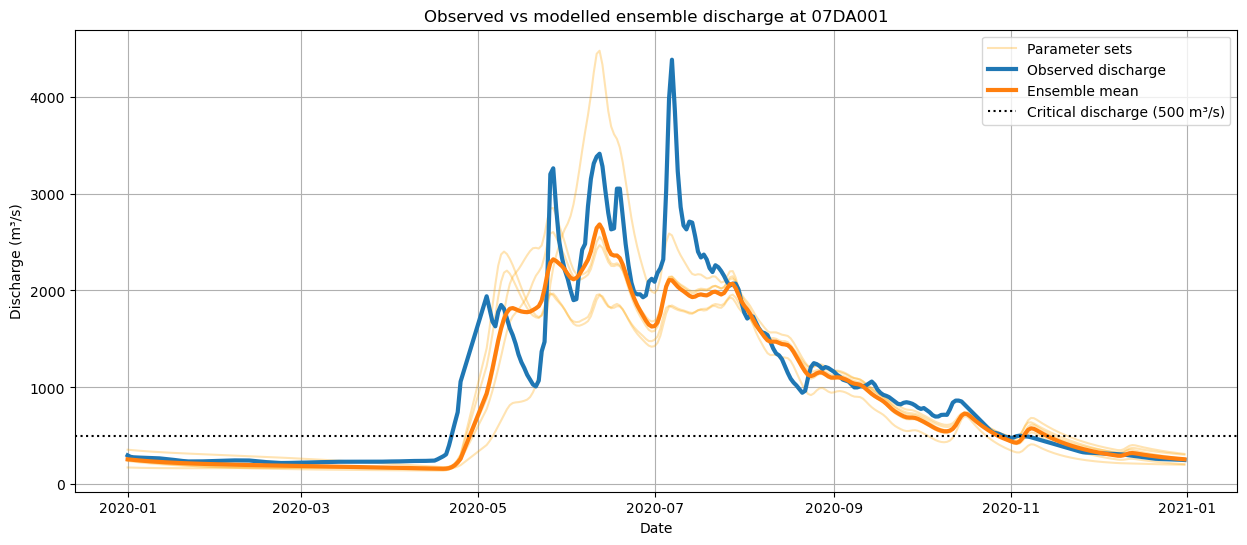

In [34]:
# Plot for selected year

selected_year = 2020

plot_ensemble(
    ensemble_data=ensemble_data,
    plot_start=pd.to_datetime(f"{selected_year}-01-01"),
    plot_end=pd.to_datetime(f"{selected_year}-12-31"))

**Figure 17:** Validation results showing observed and ERA5 discharge for 2020. 

<Figure size 640x480 with 0 Axes>

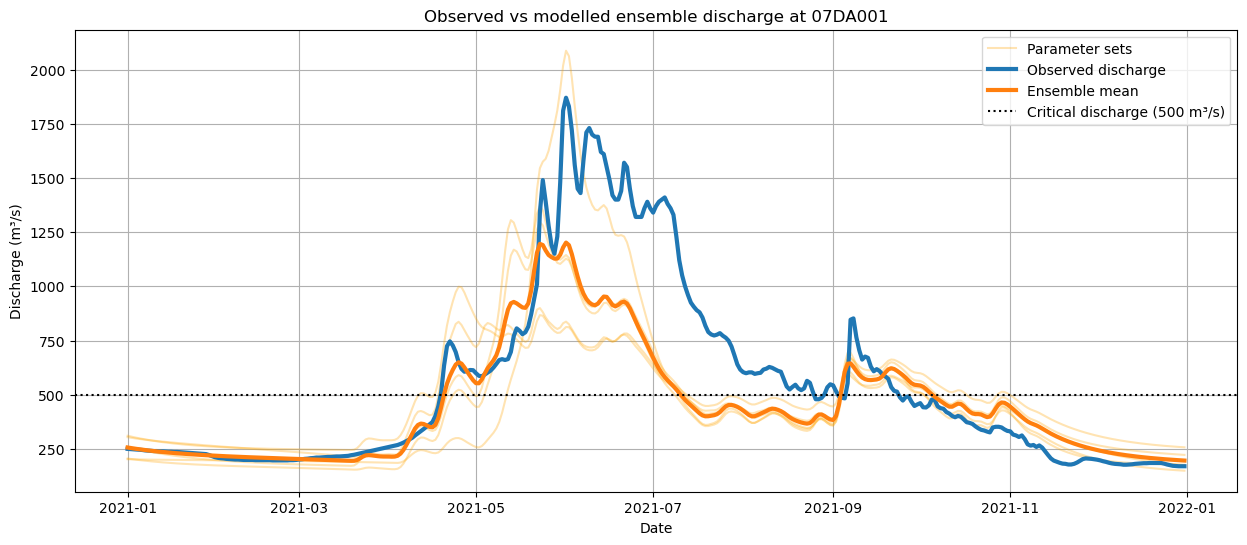

In [35]:
# Plot for selected year

selected_year = 2021

plot_ensemble(
    ensemble_data=ensemble_data,
    plot_start=pd.to_datetime(f"{selected_year}-01-01"),
    plot_end=pd.to_datetime(f"{selected_year}-12-31"))

**Figure 18:** Validation results showing observed and ERA5 discharge for 2021. 

<Figure size 640x480 with 0 Axes>

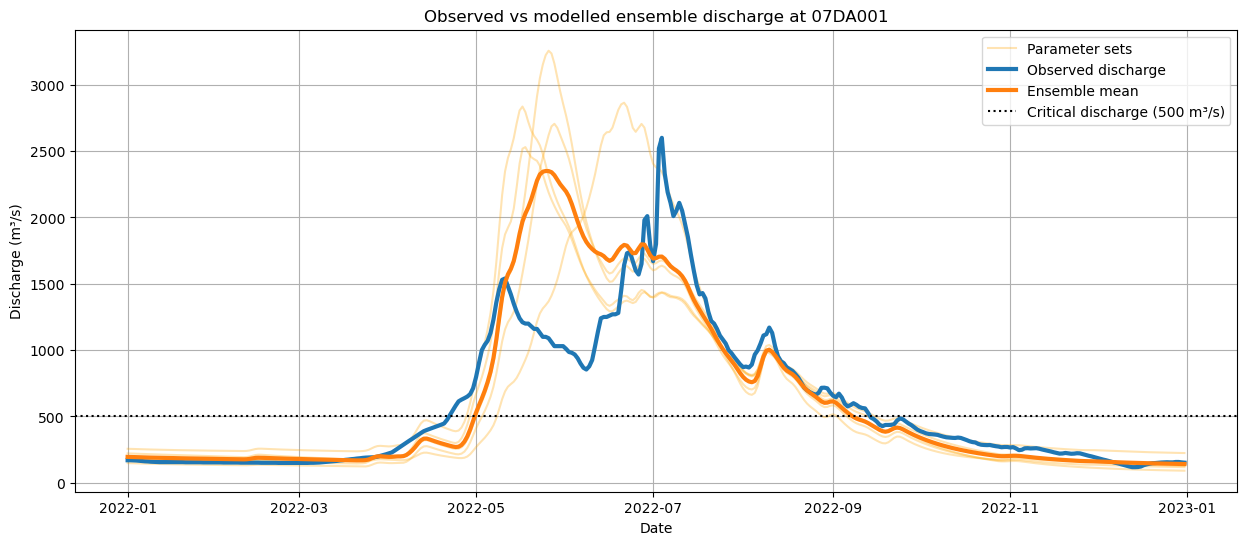

In [36]:
# Plot for selected year

selected_year = 2022

plot_ensemble(
    ensemble_data=ensemble_data,
    plot_start=pd.to_datetime(f"{selected_year}-01-01"),
    plot_end=pd.to_datetime(f"{selected_year}-12-31"))

**Figure 19:** Validation results showing observed and ERA5 discharge for 2022. 

<Figure size 640x480 with 0 Axes>

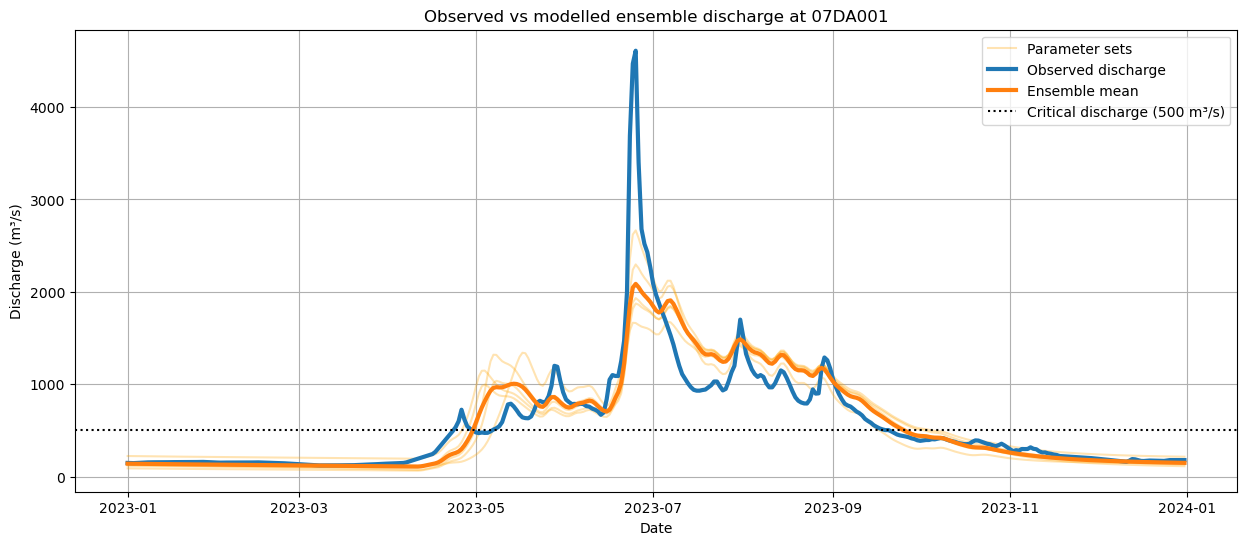

In [37]:
# Plot for selected year

selected_year = 2023

plot_ensemble(
    ensemble_data=ensemble_data,
    plot_start=pd.to_datetime(f"{selected_year}-01-01"),
    plot_end=pd.to_datetime(f"{selected_year}-12-31"))

**Figure 20:** Validation results showing observed and ERA5 discharge for 2023. 

<Figure size 640x480 with 0 Axes>

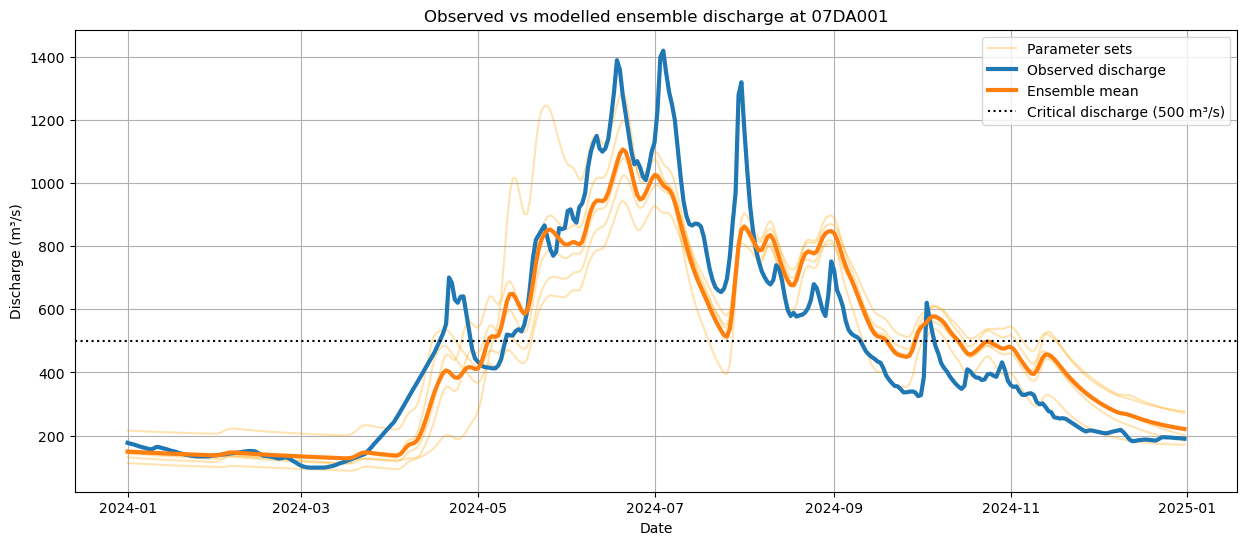

In [38]:
# Plot for selected year

selected_year = 2024

plot_ensemble(
    ensemble_data=ensemble_data,
    plot_start=pd.to_datetime(f"{selected_year}-01-01"),
    plot_end=pd.to_datetime(f"{selected_year}-12-31"))

**Figure 21:** Validation results showing observed and ERA5 discharge for 2024. 